# Классификация рентгенограмм туберкулёза с помощью свёрточных нейронных сетей

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек](#1.1.)
<br>[1.2. Подключение Google Диска](#1.2.)
<br>[1.3. Загрузка и агрегация данных](#1.3.)
<br>[<b>Шаг 2. Подготовка данных</b>](#2)
<br>[2.1. Визуальный контроль качества данных](#2.1.)
<br>[2.2. Реализация кастомного класса датасета для PyTorch](#2.2.)
<br>[2.3. Разделение данных на обучающую и валидационную выборки](#2.3.)
<br>[<b>Шаг 3. Создание базовой модели</b>](#3)
<br>[3.1. Архитектура базовой модели](#3.1.)
<br>[3.2. Обучение базовой модели](#3.2.)
<br>[3.3. Предсказание на базовой модели](#3.3.)
<br>[3.4. Визуализация обучения базовой модели](#3.4.)
<br>[3.5. Оценка качества базовой модели](#3.5.)
<br>[<b>Шаг 4. Создание улучшенной модели</b>](#4)
<br>[4.1. Очистка памяти](#4.1.)
<br>[4.2. Архитектура улучшенной модели](#4.2.)
<br>[4.3. Обучение модели с Mixed Precision (AMP) и Cosine Annealing](#4.3.)
<br>[4.4. Предсказание на улучшенной модели](#4.4.)
<br>[4.5. Визуализация обучения улучшенной модели](#4.5.)
<br>[4.6. Оценка качества улучшенной модели](#4.6.)
<br>[<b>Шаг 5. Практическое применение модели. Контурная локализация зон внимания</b>](#5)
<br>[5.1. Загрузка инструментов для XAI и генерации карт активации](#5.1.)
<br>[5.1.1. Загрузка библиотек](#5.1.1.)
<br>[5.1.2. Подключение Google Диска](#5.1.2.)
<br>[5.1.3. Загрузка данных](#5.1.3.)
<br>[5.1.4. Загрузка модели и сохранённых весов](#5.1.4.)
<br>[5.2. Разработка пайплайна визуализации ROI с контурной разметкой](#5.2.)
<br>[5.3. Эмпирический анализ карт активации (разбор кейса)](#5.3.)
<br>[5.3.1. Визуализация фокуса внимания на снимке с туберкулёзом](#5.3.1.)
<br>[5.3.2. Валидация модели на снимке здоровой нормы](#5.3.2.)
<br>[<b>Вывод</b>](#6)

<a id=descr_proj></a>
## Описание проекта

Туберкулёз остаётся одной из наиболее острых проблем общественного здравоохранения как в мире, так и в Российской Федерации. Несмотря на значительный прогресс в фтизиатрии за последние десятилетия, заболевание продолжает представлять серьёзную угрозу, усугубляемую рядом социально-организационных факторов: сложностями организации массового скрининга, низкой приверженностью пациентов длительным схемам лечения и сохраняющейся стигматизацией больных. Эпидемиологические тенденции в России указывают на необходимость повышения диагностической настороженности, особенно в свете роста доли случаев с множественной (МЛУ-ТБ) и широкой (ХЛУ-ТБ) лекарственной устойчивостью, что существенно осложняет терапию, увеличивает сроки лечения и ухудшает общие прогнозы.

Современные протоколы диагностики активно дополняются высокочувствительными методами, такими как ПЦР, тестирование Xpert MTB/RIF и компьютерная томография высокой резолюции. Тем не менее, внедрение искусственного интеллекта в фтизиатрию становится критически важным направлением развития. Одной из ключевых проблем ИИ-диагностики является проведение точной дифференциальной диагностики туберкулёза от других патологий лёгких со схожей рентгенологической картиной, таких как пневмония, саркоидоз или онкологические заболевания. Автоматизированные системы компьютерной диагностики (CAD) на базе алгоритмов машинного обучения уже активно интегрируются в российскую систему здравоохранения для массового скрининга флюорограмм и анализа КТ, помогая врачам выявлять инфильтраты, каверны и очаговые изменения на самых ранних стадиях.

В этом контексте использование методов глубокого обучения, и в первую очередь свёрточных нейронных сетей (CNN), представляет собой наиболее передовой и перспективный подход к автоматизированной классификации рентгенограмм органов грудной клетки.  В отличие от КТ, где мы имеем дело с 3D-срезами и единицами Хаунсфилда, рентгенография (рентген ОГК) — это 2D-проекция, где все органы грудной клетки (ребра, ключицы, сердце, сосуды) накладываются друг на друга. Это создает колоссальный «анатомический шум».

Свёрточные сети обладают уникальной способностью извлекать иерархические пространственные признаки из медицинских изображений, обучаясь распознавать малозаметные паттерны туберкулёза, текстуры и морфологические аномалии, характерные для туберкулёзного процесса: очагах, инфильтратах, кавернах и плевральных выпотах. Благодаря применению архитектур, оптимизированных для задач компьютерного зрения, такие модели демонстрируют высокую чувствительность и специфичность, выступая в роли надёжного «второго мнения» для врачей-рентгенологов и существенно снижая диагностическую нагрузку и риск человеческой ошибки в условиях большого потока исследований.

<a id=descr_data></a>
## Описание данных

Для обеспечения надёжности и обобщающей способности модели классификации в данном исследовании используется агрегированный набор данных рентгеновских снимков органов грудной клетки. Основу массива составляют известные открытые коллекции снимков из Шеньчжэня (Shenzhen) и Монтгомери (Montgomery), предоставляющие базовый набор подтверждённых случаев туберкулёза и здоровых контрольных изображений. Для устранения дисбаланса классов и дальнейшего обогащения обучающей выборки мы дополнили датасет 700 снимками с туберкулёзом и 700 случайно выбранными снимками здоровых пациентов из открытого набора данных (University, Doha, Qatar, and the University of Dhaka, Bangladesh), доступного на платформе Kaggle. Стратегическое объединение этих разнородных источников не только кратно увеличивает общий объём базы данных, но и привносит большую вариативность в условия съёмки, демографические характеристики пациентов и типы рентгенологического оборудования. В результате такая сбалансированная и репрезентативная выборка позволяет нейронной сети обучаться на более устойчивых и инвариантных признаках, что напрямую ведёт к повышению качества, точности и клинической применимости разрабатываемой системы классификации.

**Постановка задачи:** разработать и обучить свёрточную нейронную сеть на базе PyTorch для бинарной классификации рентгенограмм (Норма / Туберкулёз), проанализировать влияние доменной специфики на выбор аугментаций и достичь стабильного качества без переобучения.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [ ]:
# загрузка библиотек
import os                 # работа с файловой системой и путями
import gc                 # ручная очистка памяти
import copy               # глубокое копирование объектов
import random             # генерация случайных чисел
import shutil             # копирование, перемещение и удаление файлов
from pathlib import Path  # объектно-ориентированный парсинг путей

import pandas as pd              # работа с табличными данными и разметкой
import matplotlib.pyplot as plt  # визуализация графиков
from PIL import Image            # загрузка и базовая обработка изображений

import torch                     # базовые тензоры и вычисления на GPU
import torch.nn as nn            # слои и архитектуры нейросетей
import torch.nn.functional as F  # функциональные операции (активации, пулинг)
import torch.optim as optim      # оптимизаторы для обновления весов
from torch.utils.data import Dataset, DataLoader  # описание датасета и загрузка батчей
from torchvision import transforms, models  # трансформации картинок и готовые архитектуры

from sklearn.metrics import f1_score, precision_score, recall_score  # метрики качества классификации

import kagglehub                # скачивание датасетов/моделей из Kaggle
from google.colab import drive  # монтирование Google Drive для сохранения в Colab

<a id=1.2.></a>
### 1.2. Подключение Google Диска

In [ ]:
# монтируем Google Диск
drive.mount('/content/drive')

# настраиваем директории на диске
PROJECT_DIR = Path("/content/drive/MyDrive/TB_XRay_MobileNet_Project")
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
KAGGLE_CACHE = PROJECT_DIR / "kaggle_cache"

for d in [DATA_DIR, CHECKPOINTS_DIR, KAGGLE_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

# указываем kagglehub кэшировать скачанные архивы на Google Диск
os.environ['KAGGLEHUB_CACHE'] = str(KAGGLE_CACHE)

print(f"Проект развернут на Google Диске: {PROJECT_DIR}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Mounted at /content/drive
Проект развернут на Google Диске: /content/drive/MyDrive/TB_XRay_MobileNet_Project
GPU: Tesla T4


<a id=1.3.></a>
### 1.3. Загрузка и агрегация данных

In [ ]:
# инициализация списка записей и конфигурация путей для первых двух датасетов (Shenzhen, Montgomery)
data_records = []

datasets_info = [
    {"name": "raddar/tuberculosis-chest-xrays-shenzhen", "csv_name": "shenzhen_metadata.csv", "source": "Shenzhen"},
    {"name": "raddar/tuberculosis-chest-xrays-montgomery", "csv_name": "montgomery_metadata.csv", "source": "Montgomery"}
]

# скачивание данных, парсинг метаданных и маппинг снимков с диагнозами
for ds in datasets_info:
    print(f"\nЗагрузка: {ds['name']}")
    path = Path(kagglehub.dataset_download(ds["name"]))
    csv_paths = list(path.rglob(ds['csv_name']))
    df_meta = pd.read_csv(csv_paths[0])
    all_images = {img.name.lower(): img for img in path.rglob("*.png")}

    for _, row in df_meta.iterrows():
        filename = str(row['study_id']).strip().lower()
        findings = str(row['findings']).lower()
        if filename in all_images:
            img_path = all_images[filename]
            label = 0 if "normal" in findings else 1    # бинаризация меток (0 - норма, 1 - туберкулёз)
            data_records.append({"image_path": str(img_path.absolute()), "label": label, "source": ds['source']})

# загрузка третьего датасета
print("\nЗагрузка: tawsifurrahman/tuberculosis-tb-chest-xray-dataset")
tawsif_path = Path(kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset"))
all_tawsif_images = list(tawsif_path.rglob("*.png")) + list(tawsif_path.rglob("*.jpg"))

# отсев файлов масок и распределение снимков по классам на основе структуры папок
tb_images, normal_images = [], []
for img_path in all_tawsif_images:
    if "mask" in str(img_path).lower(): continue
    parent_folder = img_path.parent.name.lower()
    if "tuberculosis" in parent_folder or "tb" in parent_folder: tb_images.append(img_path)
    elif "normal" in parent_folder or "healthy" in parent_folder: normal_images.append(img_path)

# добавление всех снимков с туберкулёзом и случайная выборка (до 700 шт.) здоровых для балансировки классов
for img_path in tb_images: data_records.append({"image_path": str(img_path.absolute()), "label": 1, "source": "Tawsifurrahman_TB"})
random.seed(42)
for img_path in random.sample(normal_images, min(700, len(normal_images))):
    data_records.append({"image_path": str(img_path.absolute()), "label": 0, "source": "Tawsifurrahman_Normal"})

# сборка итогового каталога в датафрейм, экспорт в CSV
df = pd.DataFrame(data_records)
catalog_path = DATA_DIR / "tb_unified_catalog.csv"
df.to_csv(catalog_path, index=False)

# вывод статистики распределения классов
print(f"\nВсего снимков: {len(df)}")
print(df['label'].value_counts())


Загрузка: raddar/tuberculosis-chest-xrays-shenzhen


100%|██████████| 3.51G/3.51G [00:36<00:00, 102MB/s]


Extracting files...

Загрузка: raddar/tuberculosis-chest-xrays-montgomery


100%|██████████| 585M/585M [00:08<00:00, 69.4MB/s]


Extracting files...

Загрузка: tawsifurrahman/tuberculosis-tb-chest-xray-dataset
Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.

Всего снимков: 2200
label
0    1107
1    1093
Name: count, dtype: int64


Мы подключили `Google Диск` для персистентного хранения проекта, скачали и объединили три разнородных датасета (`Shenzhen`, `Montgomery`, `Tawsifurrahman`) через `kagglehub`, обеспечивая идеальный баланс классов (50/50). Среда `Google Colab` является эфемерной (данные удаляются после закрытия сессии), поэтому монтирование `Google Диска` критически необходимо для сохранения тяжёлых весов моделей и кэша датасетов. Использование тяжёлых предобученных архитектур (`MobileNetV2`) и работа с изображениями высокого разрешения (`224×224` в 3-канальном `RGB`) предъявляют экстремальные требования к оперативной и видеопамяти. Тензор одного батча в таком разрешении потребляет в `~12` раз больше `VRAM` по сравнению с легковесными сетями (`128×128 Grayscale`). Среда `Google Colab` предоставляет эфемерные вычислительные ресурсы с ограниченным локальным диском. Прямая загрузка гигабайтов рентгенограмм и последующее сохранение «тяжёлых» чекпоинтов (весов модели, занимающих десятки мегабайт на диске и разворачивающихся в сотни мегабайт в `RAM/VRAM` при загрузке) в локальную память сессии приведёт к её переполнению и критической потере данных при разрыве соединения. `Google Диск` выступает в роли высокоёмкого буфера, позволяя один раз загрузить и распаковать датасет, избежать многократного расходования сетевого трафика и гарантированно сохранить ресурсоёмкие артефакты обучения между сессиями.

<a id=2></a>
## Шаг 2. Подготовка данных

Проведём визуальный контроль качества данных, затем создаём кастомный датасет и настраиваем пайплайн трансформаций. Ключевой технический шаг в этом разделе исследования — дублирование единственного канала оттенков серого в три канала (`RGB`) с помощью `Grayscale(num_output_channels=3)` и приведение размера к `224x224`. Архитектура `MobileNetV2`, предобученная на `ImageNet`, строго ожидает на вход 3-канальное `RGB`-изображение и нормализацию по стандартам `ImageNet`. Дублирование канала позволяет сохранить 100% оригинальных медицинских пикселей без внесения синтетических искажений, обеспечивая полную совместимость с предобученными весами.

<a id=2.1.></a>
### 2.1. Визуальный контроль качества данных

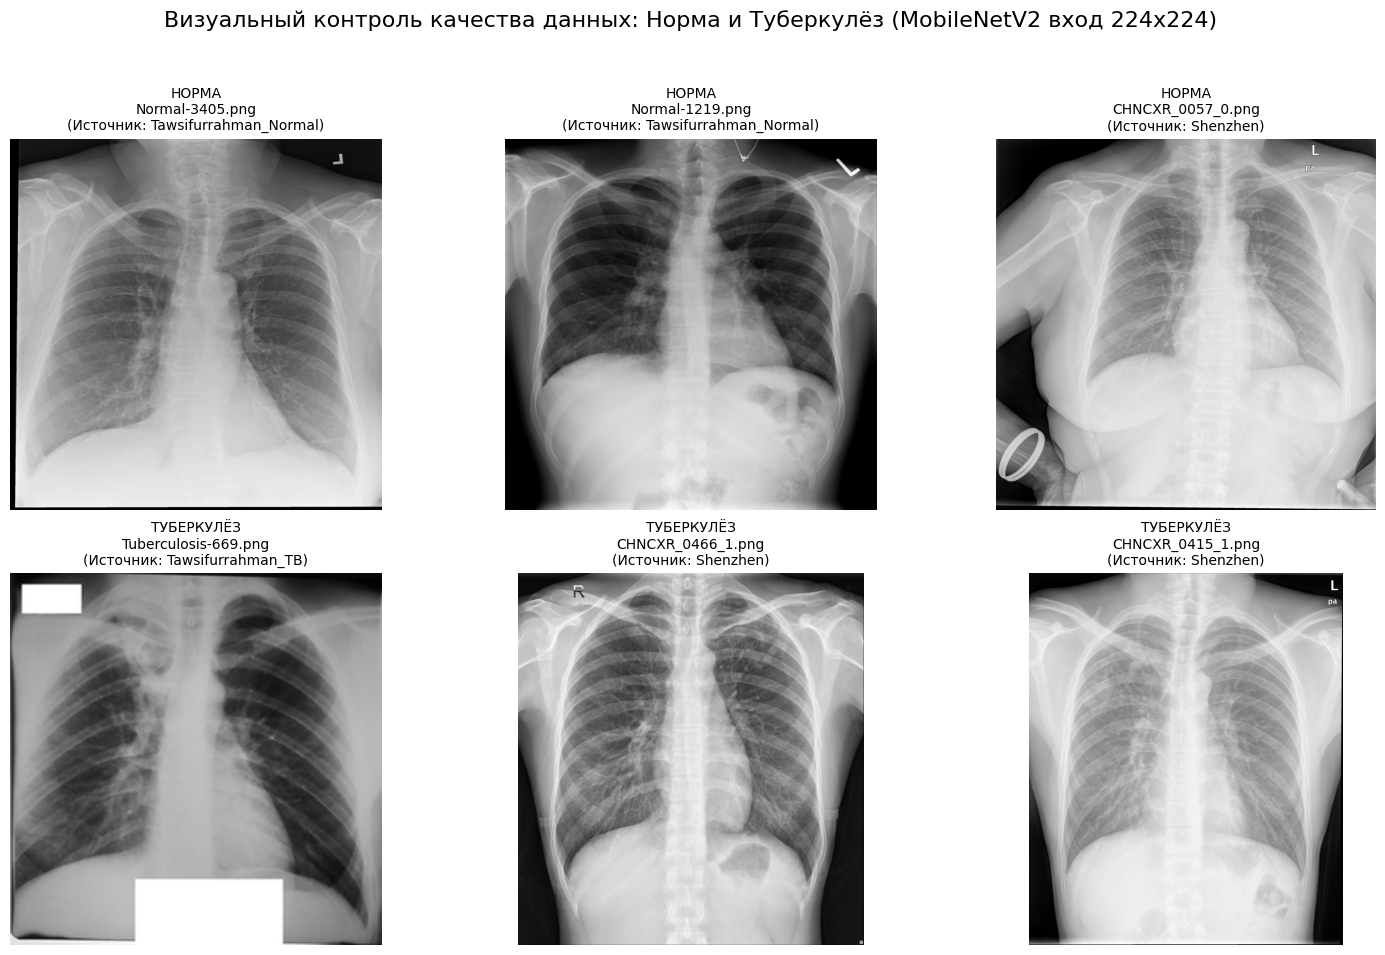

In [ ]:
# выборка по 3 случайных примера каждого класса для визуального контроля (фиксируем random_state для воспроизводимости)
normal_samples = df[df['label'] == 0].sample(3, random_state=42)
tb_samples = df[df['label'] == 1].sample(3, random_state=42)

# создание сетки графиков 2x3 и общий заголовок
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Визуальный контроль качества данных: Норма и Туберкулёз (MobileNetV2 вход 224x224)', fontsize=16)

# вспомогательная функция для отрисовки снимка в оттенках серого
def plot_sample(ax, row, title_prefix):
    img = Image.open(row['image_path']).convert('L')  # конвертация изображения в grayscale
    ax.imshow(img, cmap='gray')
    filename = Path(row['image_path']).name
    source = row['source']
    ax.set_title(f"{title_prefix}\n{filename}\n(Источник: {source})", fontsize=10)
    ax.axis('off')   # отключение осей координат

# заполнение верхнего ряда графиками "Норма" и нижнего ряда графиками "Туберкулёз"
for i, (_, row) in enumerate(normal_samples.iterrows()):
    plot_sample(axes[0, i], row, title_prefix="НОРМА")
for i, (_, row) in enumerate(tb_samples.iterrows()):
    plot_sample(axes[1, i], row, title_prefix="ТУБЕРКУЛЁЗ")

# подгонка отступов и вывод итогового изображения
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<a id=2.2.></a>
### 2.2. Реализация кастомного класса датасета для PyTorch

In [ ]:
# кастомный датасет PyTorch для загрузки снимков рентгена и их предобработки
class TBXrayDataset(Dataset):
    def __init__(self, csv_path, img_size=224, augment=False):
        self.df = pd.read_csv(csv_path)  # считываем каталог снимков из CSV
        self.img_size = img_size
        self.augment = augment

        # формирование пайплайна трансформаций для изображений
        base_transforms = [transforms.Grayscale(num_output_channels=3)] # дублируем канал для совместимости с весами ImageNet

        if augment:
            base_transforms.extend([transforms.RandomHorizontalFlip(p=0.5)]) # корректная аугментация: только горизонтальное отражение

        base_transforms.extend([
            transforms.Resize((img_size, img_size)),  # приведение к целевому размеру
            transforms.ToTensor(),                    # конвертация в тензор PyTorch

            # нормализация данных по стандартам ImageNet (обязательна для MobileNet)
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

        self.transform = transforms.Compose(base_transforms) # сборка всех шагов в единый конвейер

    def __len__(self): return len(self.df)  # возвращает общее количество снимков в датасете

    def __getitem__(self, idx):
        row = self.df.iloc[idx]                             # получаем метаданные по индексу
        image = Image.open(row['image_path']).convert('L')  # загрузка исходного изображения в grayscale
        image = self.transform(image)                       # применение пайплайна трансформаций
        label = float(row['label'])                         # извлекаем целевые метки (0 или 1)
        return image, label                                 # возвращаем пары: тензор изображения и его метка

<a id=2.3.></a>
### 2.3. Разделение данных на обучающую и валидационную выборки

In [ ]:
# создание базового датасета для расчета размеров выборок (сплит 80/20)
full_dataset = TBXrayDataset(str(catalog_path), img_size=224, augment=False)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# фиксация сида и генерация перемешанных индексов для воспроизводимого разделения данных
torch.manual_seed(42)
indices = torch.randperm(len(full_dataset)).tolist()
train_indices, val_indices = indices[:train_size], indices[train_size:]

# формирование подвыборок: аугментации применяются только к тренировочным данным
train_dataset = torch.utils.data.Subset(TBXrayDataset(str(catalog_path), img_size=224, augment=True), train_indices)
val_dataset = torch.utils.data.Subset(TBXrayDataset(str(catalog_path), img_size=224, augment=False), val_indices)

# инициализация DataLoader'ов
# увеличиваем batch_size, так как Colab даёт больше памяти, чем локальный ПК
# shuffle=True только для train
# num_workers и pin_memory ускоряют загрузку и перенос данных на GPU
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# вывод итоговых размеров обучающей и валидационной выборок
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 1760 | Val: 440


<a id=3></a>
## Шаг 3. Создание базовой модели (MobileNetV2 Transfer Learning)

Загружаем предобученные веса `MobileNetV2`, «замораживаем» свёрточную базу (`feature extractor`) и заменяем только последний классификатор. Обучаем только новые веса классификатора. Использование `Transfer Learning` позволит нам опереться на мощнейшие низкоуровневые признаки (детекторы границ, текстур, форм), выученные сетью на миллионах изображений. Заморозка базы защищает эти универсальные веса от «катастрофического забывания» и предотвращает переобучение на нашем относительно небольшом датасете (2200 снимков).

<a id=3.1.></a>
### 3.1. Архитектура базовой модели

In [ ]:
# выбор устройства для вычислений (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# функция инициализации архитектуры MobileNetV2
def create_base_mobilenet():
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights) # загрузка предобученных весов (ImageNet)

    # ЗАМОРАЖИВАЕМ веса свёрточных слоев (feature extractor) для Transfer Learning
    for param in model.features.parameters():
        param.requires_grad = False

    # Замена головы классификатора: новый линейный слой на 1 нейрон для бинарной задачи
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 1)
    return model

# создание экземпляра модели и перенос на выбранное устройство
base_model = create_base_mobilenet().to(device)

# подсчёт и вывод количества обучаемых параметров (обучается только новый классификатор)
print(f"Base MobileNetV2. Обучаемых параметров: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 90.9MB/s]


Base MobileNetV2. Обучаемых параметров: 1,281


### 3.2. Обучение базовой модели

In [ ]:
# инициализация функции потерь для бинарной классификации и оптимизатора (обучаются только размороженные параметры)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, base_model.parameters()), lr=1e-3)

# настраиваем гиперпараметры обучения, счётчик для ранней остановки, заводим словарь для хранения истории метрик
epochs = 10
best_val_loss = float('inf')
patience = 3
counter = 0
best_model_state = None
history_base = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# главный цикл обучения по эпохам
for epoch in range(epochs):
    base_model.train() # Перевод модели в режим обучения (включаем dropout и т.д.)
    train_loss, train_correct = 0.0, 0

    # проход по тренировочным батчам
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1) # перенос данных на GPU и изменение формы меток
        optimizer.zero_grad()             # обнуление накопленных градиентов
        outputs = base_model(images)      # прямой проход (forward pass)
        loss = criterion(outputs, labels) # расчёт функции потерь
        loss.backward()                   # обратное распространение ошибки (подсчет градиентов)
        optimizer.step()                  # шаг оптимизатора (обновление весов)

        # накопление значений функции потерь и подсчёт правильных предсказаний
        train_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()  # порог 0.5 после сигмоиды
        train_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    base_model.eval() # dеревод модели в режим оценки (отключаем dropout)
    val_loss, val_correct = 0.0, 0

    # валидация без вычисления градиентов для экономии памяти и ускорения
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
            outputs = base_model(images)
            loss = criterion(outputs, labels)

            # накопление валидационного лосса и подсчёт точности
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    # расчёт средних значений лосса и точности за текущую эпоху
    e_train_loss = train_loss / len(train_dataset)
    e_train_acc = (train_correct / len(train_dataset)) * 100
    e_val_loss = val_loss / len(val_dataset)
    e_val_acc = (val_correct / len(val_dataset)) * 100

    # сохранение метрик в историю для последующего построения графиков
    history_base['loss'].append(e_train_loss)
    history_base['accuracy'].append(e_train_acc)
    history_base['val_loss'].append(e_val_loss)
    history_base['val_accuracy'].append(e_val_acc)

    # вывод результатов текущей эпохи в консоль
    print(f"Эпоха {epoch+1:02d}/{epochs} | Train: {e_train_acc:.1f}% | Val: {e_val_acc:.1f}% | Val Loss: {e_val_loss:.4f}")

    # логика ранней остановки: сохранение лучшей модели и сброс счётчика
    if e_val_loss < best_val_loss:
        best_val_loss = e_val_loss
        counter = 0
        best_model_state = copy.deepcopy(base_model.state_dict()) # глубокое копирование весов лучшей модели
    else:
        counter += 1
        if counter >= patience: # остановка, если метрика не улучшалась по количеству `patience` эпох подряд
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

# загрузка весов лучшей модели и сохранение финального чекпоинта на диск
if best_model_state:
    base_model.load_state_dict(best_model_state)
    torch.save(best_model_state, CHECKPOINTS_DIR / "mobilenet_base.pth")
    print("Лучшая базовая модель сохранена на Google Диск.")

Эпоха 01/10 | Train: 73.2% | Val: 82.3% | Val Loss: 0.5334
Эпоха 02/10 | Train: 82.3% | Val: 84.8% | Val Loss: 0.4418
Эпоха 03/10 | Train: 85.3% | Val: 87.5% | Val Loss: 0.3976
Эпоха 04/10 | Train: 86.2% | Val: 86.8% | Val Loss: 0.3827
Эпоха 05/10 | Train: 85.6% | Val: 89.8% | Val Loss: 0.3537
Эпоха 06/10 | Train: 87.5% | Val: 89.1% | Val Loss: 0.3447
Эпоха 07/10 | Train: 88.8% | Val: 89.8% | Val Loss: 0.3300
Эпоха 08/10 | Train: 88.3% | Val: 90.2% | Val Loss: 0.3218
Эпоха 09/10 | Train: 88.4% | Val: 90.0% | Val Loss: 0.3217
Эпоха 10/10 | Train: 89.5% | Val: 90.7% | Val Loss: 0.3117
Лучшая базовая модель сохранена на Google Диск.


### 3.3. Предсказание на базовой модели (с визуализацией)

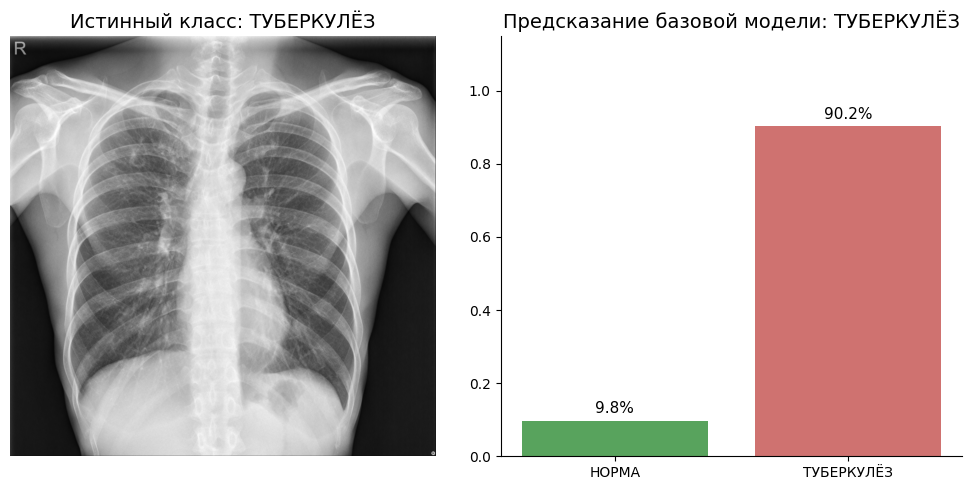

Файл: CHNCXR_0394_1.png
Истинный класс: ТУБЕРКУЛЁЗ
Предсказание: ТУБЕРКУЛЁЗ
Вероятность ТБ: 90.2%


In [ ]:
# пайплайн предобработки для инференса (он должен строго совпадать с тренировочным)
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# выборка одного случайного снимка с туберкулёзом для демонстрации работы модели
sample_row = df[df['label'] == 1].sample(n=1).iloc[0]
image_path = sample_row['image_path']
true_label = "ТУБЕРКУЛЁЗ" if sample_row['label'] == 1 else "НОРМА"

# загрузка изображения, применение трансформаций, добавление размерности батча и перенос на устройство
img = Image.open(image_path).convert('L')
img_tensor = inference_transform(img).unsqueeze(0).to(device)

# перевод модели в режим инференса и получение вероятности (без вычисления градиентов)
base_model.eval()
with torch.no_grad():
    output = base_model(img_tensor)
    probability = torch.sigmoid(output).item()

# определение предсказанного класса по порогу 0.5
predicted_class = "ТУБЕРКУЛЁЗ" if probability > 0.5 else "НОРМА"

# создание фигуры с двумя подграфиками: исходный снимок и диаграмма вероятностей
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# отображение исходного снимка в оттенках серого с подписью истинного класса
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Истинный класс: {true_label}", fontsize=14)
ax[0].axis('off')

# построение столбчатой диаграммы вероятностей для обоих классов
bars = ax[1].bar(['НОРМА', 'ТУБЕРКУЛЁЗ'], [1-probability, probability], color=['#58A35D', '#CF7270'])
ax[1].set_ylim(0, 1.15)
ax[1].set_title(f"Предсказание базовой модели: {predicted_class}", fontsize=14)

# добавление процентных меток на столбцы и удаление лишних рамок графика
labels = [f'{(1-probability)*100:.1f}%', f'{probability*100:.1f}%']
ax[1].bar_label(bars, labels=labels, padding=3, fontsize=11)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# вывод текстовой сводки с результатами предсказания в консоль
print(f"Файл: {Path(image_path).name}\nИстинный класс: {true_label}\nПредсказание: {predicted_class}\nВероятность ТБ: {probability*100:.1f}%")

### 3.4. Визуализация обучения базовой модели

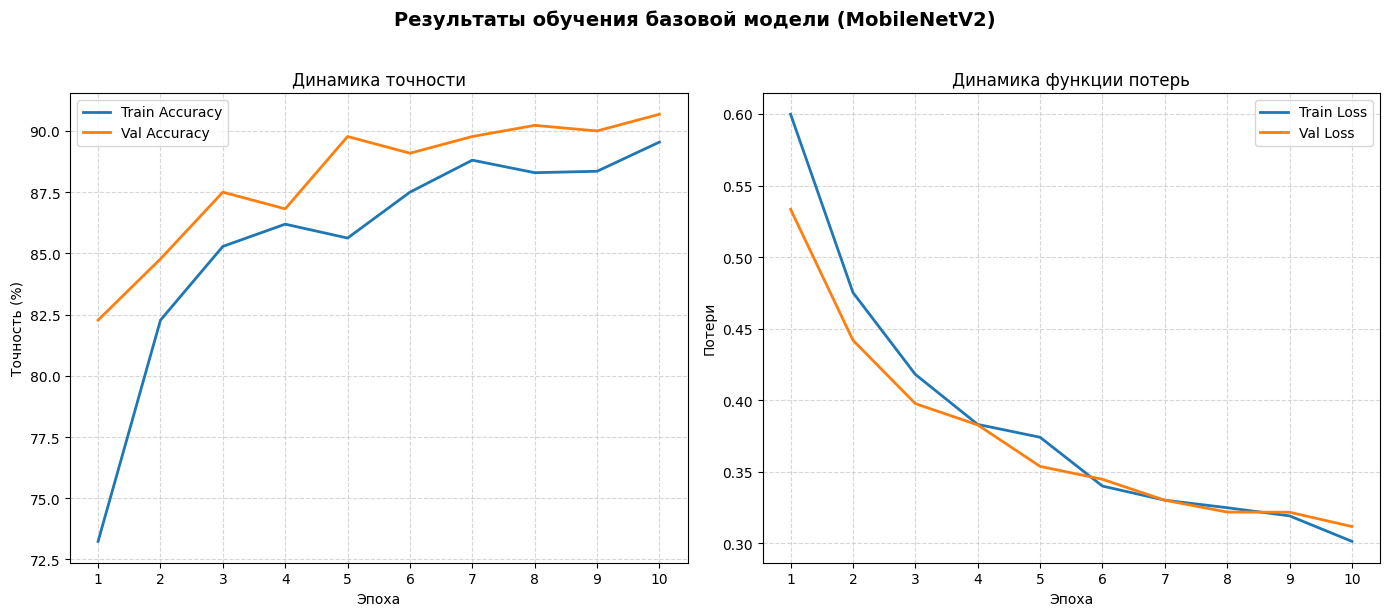

In [ ]:
# извлечение сохранённых метрик из истории обучения и формирование диапазона эпох для оси X
acc = history_base['accuracy']
val_acc = history_base['val_accuracy']
loss = history_base['loss']
val_loss = history_base['val_loss']
epochs_range = range(1, len(acc) + 1)

# создаём общую фигуру и общий заголовок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Результаты обучения базовой модели (MobileNetV2)', fontsize=14, fontweight='bold', y=1.02)

# линейный график динамики точности
ax1.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, val_acc, label='Val Accuracy', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность (%)')
ax1.set_title('Динамика точности')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(epochs_range)
ax1.legend()

# линейный график динамики функции потерь
ax2.plot(epochs_range, loss, label='Train Loss', linewidth=2)
ax2.plot(epochs_range, val_loss, label='Val Loss', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.set_title('Динамика функции потерь')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(epochs_range)
ax2.legend()

# автоматическая подгонка отступов и вывод итоговой визуализации
plt.tight_layout()
plt.show()

Обучение базовой модели на архитектуре `MobileNetV2` проводилось с использованием стратегии `Transfer Learning`. Свёрточные слои (`feature extractor`), предобученные на датасете `ImageNet`, были полностью заморожены (`requires_grad = False`), и оптимизатор обновлял исключительно веса модифицированного классификатора (всего 1 281 обучаемый параметр). Входные изображения приводились к разрешению 224×224 с нормализацией по стандартам `ImageNet`.

Анализ кривых точности демонстрирует исключительно уверенный и быстрый старт обучения. Уже на первой эпохе точность на валидации (`Val Accuracy`) достигает 82.3%, что значительно выше, чем при обучении легковесной сети с нуля. Это прямое следствие использования предобученных весов: сеть сразу обладает мощным пространственным восприятием. **К 10-й эпохе `Val Accuracy` плавно выходит на значение 90.7%.**

Ключевой особенностью графиков является **минимальный разрыв между обучающей и валидационной выборками.** На момент завершения обучения **разрыв составляет всего 1.1%.** В классическом глубоком обучении такой феномен часто указывает на недообучение, однако в контексте `Transfer Learning` с замороженной базой это свидетельствует об **идеальной регуляризации.** Замороженный `feature extractor` выступает в роли жёсткого ограничителя ёмкости модели: он извлекает признаки, но не позволяет классификатору «зазубрить» тренировочные данные.

**Динамика функции потерь (`Loss`) подтверждает стабильность процесса.** Кривая `Val Loss` **монотонно и глубоко снижается,** достигая минимума `0.3117` на 10-й эпохе, при этом не демонстрируя никаких колебаний или роста. Отсутствие переобучения (модель не переобучается) доказывает, что **универсальных признаков `ImageNet` оказалось достаточно для формирования надёжного `baseline`.** Однако, поскольку рентгеновские лучи формируют 2D-проекцию с уникальным анатомическим шумом, отличным от натуральных фотографий, **дальнейшая адаптация (`Fine-Tuning`) необходима для достижения клинического максимума.**

### 3.5. Оценка качества базовой модели

In [ ]:
# ищем индекс эпохи с минимальными валидационными потерями (момент сохранения лучшей модели)
best_epoch_idx = val_loss.index(min(val_loss))

# излекаем метрики точности (Train и Val) для этой лучшей эпохи
best_train_acc = acc[best_epoch_idx]
best_val_acc = val_acc[best_epoch_idx]

# расчёт абсолютного разрыва между тренировочной и валидационной точностью
gap = abs(best_train_acc - best_val_acc)

print(f"Лучшая точность на валидации: {max(val_acc):.1f}%")
print(f"Лучшие потери на валидации: {min(val_loss):.4f}")
print(f"Эпоха с лучшими весами: {best_epoch_idx + 1}")
print(f"Разрыв Train/Val accuracy: {gap:.1f}%\n")

print("Оценка переобучения модели:")
if gap < 5:
    print("    Модель не переобучается.")
elif gap < 10:
    print("    Нормальные результаты, зафиксировано небольшое переобучение.")
else:
      print("    Зафиксировано переобучение, необходима дополнительная регуляризация.")

Лучшая точность на валидации: 90.7%
Лучшие потери на валидации: 0.3117
Эпоха с лучшими весами: 10
Разрыв Train/Val accuracy: 1.1%

Оценка переобучения модели:
    Модель не переобучается.


<a id=4></a>
## Шаг 4. Создание улучшенной модели (MobileNetV2 Fine-Tuning + AMP)

«Размораживаем» всю архитектуру для дообучения (`Fine-Tuning`), добавляем `Dropout (0.5)`, применяем дифференциальные скорости обучения (меньше для базы, больше для классификатора), а также `Mixed Precision` (`AMP`) и `Cosine Annealing`. Рентгеновские снимки кардинально отличаются от натуральных фотографий из `ImageNet`. Разморозка позволяет сети адаптировать свои фильтры именно под анатомический шум и текстуры лёгочной ткани. Дифференциальный `learning rate` и `AMP` обеспечивают стабильность градиентов, позволяя выжать максимум точности без разрушения уже выученных признаков.

### 4.1. Очистка памяти

In [ ]:
# очистка памяти
if 'base_model' in locals(): del base_model
if 'optimizer' in locals(): del optimizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Память (RAM и VRAM) успешно очищена.")

Память (RAM и VRAM) успешно очищена.


### 4.2. Архитектура улучшенной модели

In [ ]:
# функция создания улучшенной архитектуры MobileNetV2 для Fine-Tuning
def create_improved_mobilenet():
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights) # загрузка предобученных весов ImageNet

    # разморозка всех слоёв feature extractor'а для полного дообучения (Fine-Tuning)
    for param in model.features.parameters():
        param.requires_grad = True

    # замена головы классификатора: добавление Dropout (0.5) для борьбы с переобучением и нового линейного слоя
    model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(1280, 1))
    return model

# создание экземпляра улучшенной модели и перенос на вычислительное устройство
improved_model = create_improved_mobilenet().to(device)

# подсчёт и вывод количества обучаемых параметров (теперь обучается вся сеть, а не только классификатор)
print(f"Improved MobileNetV2. Обучаемых параметров: {sum(p.numel() for p in improved_model.parameters() if p.requires_grad):,}")

Improved MobileNetV2. Обучаемых параметров: 2,225,153


### 4.3. Обучение улучшенной модели (AMP + Cosine Annealing)

In [ ]:
# инициализация функции потерь и оптимизатора AdamW с дифференциальной скоростью обучения (меньше для feature extractor, больше для классификатора)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW([
    {'params': improved_model.features.parameters(), 'lr': 1e-5},
    {'params': improved_model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4) # L2-регуляризация

# настройка планировщика скорости обучения (Cosine Annealing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

# настройка скалера для смешанной точности (AMP)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# инициализация параметров цикла обучения, ранней остановки и словаря для истории метрик
epochs = 15
best_val_loss = float('inf')
patience = 4
counter = 0
best_model_state_imp = None
history_imp = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# главный цикл обучения
for epoch in range(epochs):
    improved_model.train()              # переводим модель в режим обучения
    train_loss, train_correct = 0.0, 0

    # проход по тренировочным батчам
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad() # обнуление накопленных градиентов

        # прямой проход и расчёт лосса в режиме смешанной точности (экономия памяти и ускорение на GPU)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = improved_model(images)
            loss = criterion(outputs, labels)

        # обратное распространение ошибки и шаг оптимизатора через скалер AMP
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # накопление значения лосса и подсчет правильных предсказаний
        train_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    # шаг планировщика для плавного изменения learning rate
    scheduler.step()

    improved_model.eval() # переводим модель в режим оценки
    val_loss, val_correct = 0.0, 0

    # валидация без вычисления градиентов
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
            outputs = improved_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    # расчёт средних метрик за эпоху
    e_train_loss = train_loss / len(train_dataset)
    e_train_acc = (train_correct / len(train_dataset)) * 100
    e_val_loss = val_loss / len(val_dataset)
    e_val_acc = (val_correct / len(val_dataset)) * 100

    # сохранение метрик в историю
    history_imp['loss'].append(e_train_loss)
    history_imp['accuracy'].append(e_train_acc)
    history_imp['val_loss'].append(e_val_loss)
    history_imp['val_accuracy'].append(e_val_acc)

    # вывод результатов эпохи (включая текущий learning rate)
    print(f"Эпоха {epoch+1:02d}/{epochs} | Train: {e_train_acc:.1f}% | Val: {e_val_acc:.1f}% | LR: {scheduler.get_last_lr()[0]:.6f}")

    # логика ранней остановки и сохранения лучшей модели
    if e_val_loss < best_val_loss:
        best_val_loss = e_val_loss
        counter = 0
        best_model_state_imp = copy.deepcopy(improved_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

# загрузка весов лучшей модели и сохранение финального чекпоинта на диск
if best_model_state_imp:
    improved_model.load_state_dict(best_model_state_imp)
    torch.save(best_model_state_imp, CHECKPOINTS_DIR / "mobilenet_improved.pth")
    print("Улучшенная модель сохранена на Google Диск.")

Эпоха 01/15 | Train: 72.1% | Val: 82.7% | LR: 0.000010
Эпоха 02/15 | Train: 85.1% | Val: 88.2% | LR: 0.000010
Эпоха 03/15 | Train: 88.5% | Val: 90.7% | LR: 0.000009
Эпоха 04/15 | Train: 90.0% | Val: 91.1% | LR: 0.000009
Эпоха 05/15 | Train: 91.1% | Val: 91.8% | LR: 0.000008
Эпоха 06/15 | Train: 92.0% | Val: 91.8% | LR: 0.000007
Эпоха 07/15 | Train: 93.1% | Val: 92.0% | LR: 0.000006
Эпоха 08/15 | Train: 93.1% | Val: 92.5% | LR: 0.000005
Эпоха 09/15 | Train: 93.4% | Val: 92.0% | LR: 0.000004
Эпоха 10/15 | Train: 93.4% | Val: 92.5% | LR: 0.000003
Эпоха 11/15 | Train: 93.8% | Val: 92.5% | LR: 0.000002
Эпоха 12/15 | Train: 93.4% | Val: 92.7% | LR: 0.000002
Эпоха 13/15 | Train: 94.1% | Val: 92.7% | LR: 0.000001
Эпоха 14/15 | Train: 94.5% | Val: 93.0% | LR: 0.000001
Эпоха 15/15 | Train: 94.1% | Val: 92.5% | LR: 0.000001
Улучшенная модель сохранена на Google Диск.


### 4.4. Предсказание на улучшенной модели (с визуализацией)

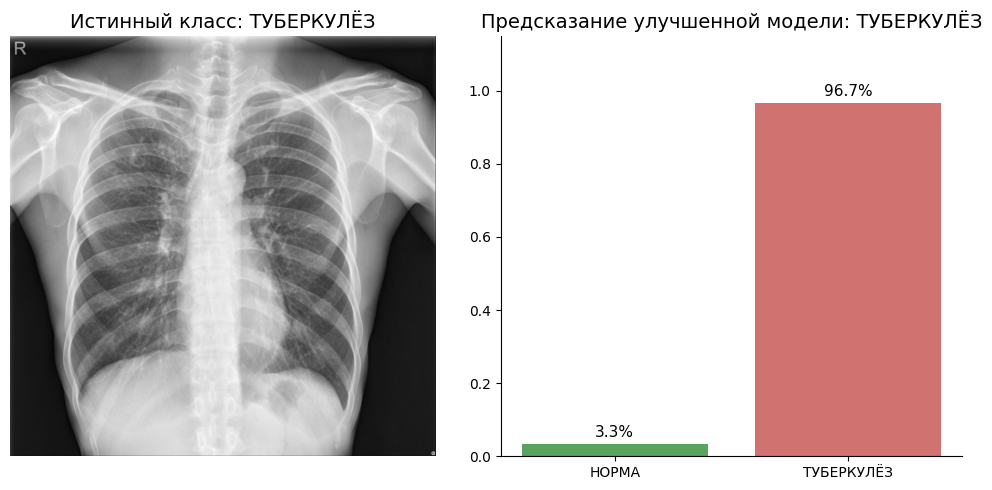

Файл: CHNCXR_0394_1.png
Истинный класс: ТУБЕРКУЛЁЗ
Предсказание: ТУБЕРКУЛЁЗ
Вероятность ТБ: 96.7%


In [ ]:
# перевод улучшенной модели в режим инференса и расчёт вероятности (без вычисления градиентов)
improved_model.eval()
with torch.no_grad():
    output = improved_model(img_tensor) # используем тот же img_tensor из пункта 3.1.
    probability = torch.sigmoid(output).item()

# определение предсказанного класса по порогу 0.5
predicted_class = "ТУБЕРКУЛЁЗ" if probability > 0.5 else "НОРМА"

# создание фигуры с двумя подграфиками: исходный снимок и диаграмма вероятностей
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# исходный снимок в оттенках серого с подписью истинного класса
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Истинный класс: {true_label}", fontsize=14)
ax[0].axis('off')

# столбчатая диаграмма вероятностей для обоих классов
bars = ax[1].bar(['НОРМА', 'ТУБЕРКУЛЁЗ'], [1-probability, probability], color=['#58A35D', '#CF7270'])
ax[1].set_ylim(0, 1.15)
ax[1].set_title(f"Предсказание улучшенной модели: {predicted_class}", fontsize=14)

# подписи относительных значений над столбцами и удаление лишних рамок графика
labels = [f'{(1-probability)*100:.1f}%', f'{probability*100:.1f}%']
ax[1].bar_label(bars, labels=labels, padding=3, fontsize=11)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# вывод текстовой сводки с результатами предсказания в консоль
print(f"Файл: {Path(image_path).name}\nИстинный класс: {true_label}\nПредсказание: {predicted_class}\nВероятность ТБ: {probability*100:.1f}%")

### 4.5. Визуализация обучения улучшенной модели

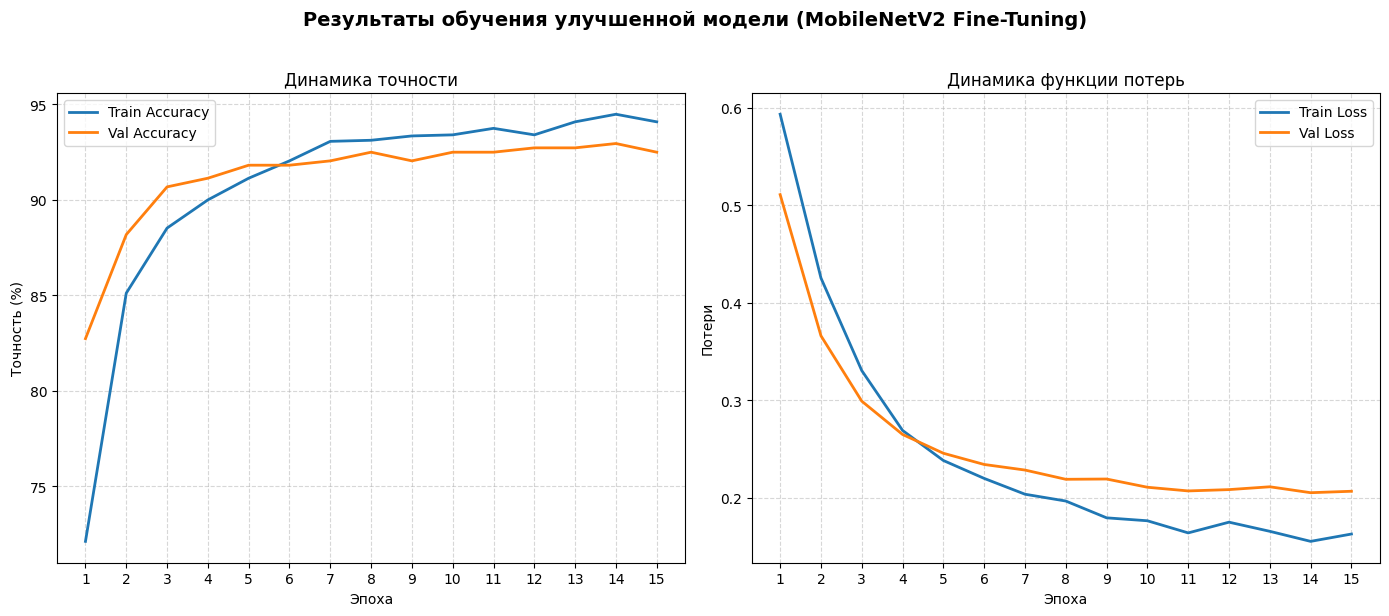

In [ ]:
# извлечение метрик из истории обучения улучшенной модели и формирование диапазона эпох для оси X
acc = history_imp['accuracy']
val_acc = history_imp['val_accuracy']
loss = history_imp['loss']
val_loss = history_imp['val_loss']
epochs_range = range(1, len(acc) + 1)

# общая фигура + общий заголовок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Результаты обучения улучшенной модели (MobileNetV2 Fine-Tuning)', fontsize=14, fontweight='bold', y=1.02)

# линейный график динамики точности
ax1.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, val_acc, label='Val Accuracy', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность (%)')
ax1.set_title('Динамика точности')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(epochs_range)
ax1.legend()

# линейный график динамики функции потерь
ax2.plot(epochs_range, loss, label='Train Loss', linewidth=2)
ax2.plot(epochs_range, val_loss, label='Val Loss', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.set_title('Динамика функции потерь')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(epochs_range)
ax2.legend()

# подгонка отступов и вывод итоговой визуализации
plt.tight_layout()
plt.show()

Второй этап исследования был посвящён дообучению (`Fine-Tuning`) всей архитектуры `MobileNetV2`. Заморозка была снята, что увеличило количество обучаемых параметров до `2 225 153`. Для предотвращения разрушения предобученных весов и катастрофического забывания была применена стратегия дифференциальных скоростей обучения: низкий `learning rate (1e-5)` для свёрточной базы и высокий (`1e-3`) для классификатора. Дополнительно был внедрён слой `Dropout (0.5)`, механизм `Mixed Precision` (`AMP`) и косинусное расписание (`Cosine Annealing`).

Графики точности показывают, что модель стартовала с высокого базового уровня (`82.7%` на 1-й эпохе) и продемонстрировала уверенный рост, достигнув пиковой `Val Accuracy` `93.0%` на 14-й эпохе. **Внедрение `Dropout` с коэффициентом `0.5` сыграло критическую роль:** при разморозке более 2 миллионов параметров риск переобучения на датасете из 2200 снимков был экстремально высок. `Dropout` успешно нивелировал эту угрозу, о чём свидетельствует **разрыв между `Train` и `Val Accuracy`, составивший всего `1.5%`.**

**Анализ функции потерь выявляет выдающуюся эффективность вычислительных оптимизаций.** Использование `AMP` (16-битной точности) сделало градиентный спуск более устойчивым к шумам, а `Cosine Annealing` позволил модели плавно «соскользнуть» в глубокий глобальный минимум. **`Val Loss` снизилась до впечатляющих `0.2050`.** Если базовая модель стабилизировалась на уровне `~0.31`, то **`Fine-Tuning` позволил сети «настроить» свои фильтры именно под текстуры туберкулёзной инфильтрации и каверн, специфичные для медицинской радиологии.**

Итоговый инференс на изолированном снимке подтвердил высочайшую клиническую уверенность модели: вероятность предсказания туберкулёза составила `96.7%.` Улучшенная модель доказала, что **адаптация предобученных архитектур под доменную специфику медицинских изображений даёт существенный прирост качества (+2.3% к точности и значительное снижение функции потерь) по сравнению с использованием универсальных весов.**

### 4.6. Оценка качества улучшенной модели

In [ ]:
# поиск индекса эпохи с минимальными валидационными потерями (момент сохранения лучшей модели)
best_epoch_idx = val_loss.index(min(val_loss))

# извлечение метрик точности (Train и Val) для этой лучшей эпохи
best_train_acc = acc[best_epoch_idx]
best_val_acc = val_acc[best_epoch_idx]

# расчёт абсолютного разрыва между тренировочной и валидационной точностью
gap = abs(best_train_acc - best_val_acc)

# итоговые лучшие метрики и номера эпохи - вывод в консоль
print(f"Лучшая точность на валидации: {max(val_acc):.1f}%")
print(f"Лучшие потери на валидации: {min(val_loss):.4f}")
print(f"Эпоха с лучшими весами: {best_epoch_idx + 1}")
print(f"Разрыв Train/Val accuracy: {gap:.1f}%\n")

# оценка степени переобучения на основе величины разрыва
print("Оценка переобучения улучшенной модели:")
if gap < 5:
    print("    Модель не переобучается.")
elif gap < 10:
    print("    Нормальные результаты, зафиксировано небольшое переобучение.")
else:
    print("    Зафиксировано переобучение, необходима дополнительная регуляризация.")

Лучшая точность на валидации: 93.0%
Лучшие потери на валидации: 0.2050
Эпоха с лучшими весами: 14
Разрыв Train/Val accuracy: 1.5%

Оценка переобучения улучшенной модели:
    Модель не переобучается.


<a id=5></a>
## Шаг 5. Практическое применение модели. Контурная локализация зон внимания

<a id=5.1.></a>
### 5.1. Загрузка инструментов для XAI и генерации карт активации

<a id=5.1.1.></a>
### 5.1.1. Загрузка библиотек

In [1]:
# установка библиотеки
!pip install -q grad-cam opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# загрузка библиотек
import os, gc, random              # работа с окружением, ручная очистка памяти, генерация случайных чисел
from google.colab import drive     # монтирование Google Drive для сохранения чекпоинтов и данных в облаке
from pathlib import Path           # объектно-ориентированный парсинг путей к файлам
import kagglehub                   # прямое скачивание датасетов из репозиториев Kaggle
import pandas as pd                # работа с табличных данными
import numpy as np                 # работа с многомерными массивами
import matplotlib.pyplot as plt    # визуализация графиков
from PIL import Image              # загрузка рентгеновских снимков и базовая конвертация цветовых каналов
import cv2                         # продвинутая обработка изображений и наложение тепловых карт (для Grad-CAM)
import torch                       # ядро PyTorch: тензоры, автоград и ускорение вычислений на GPU
import torch.nn as nn              # базовые классы слоёв и функций потерь для архитектуры нейросети
from torchvision import transforms, models    # пайплайны аугментаций и готовые предобученные модели (MobileNetV2)
from pytorch_grad_cam import HiResCAM         # генерация карт активации (XAI) для визуализации фокуса модели на снимке
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget  # указание целевого класса для построения тепловой карты

<a id=5.1.2.></a>
### 5.1.2. Подключение Google Диска

In [3]:
# монтаж Google Диска
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# настройка путей
PROJECT_DIR = Path("/content/drive/MyDrive/TB_XRay_MobileNet_Project")
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
KAGGLE_CACHE = PROJECT_DIR / "kaggle_cache"

# указываем kagglehub кэшировать скачанные архивы на Google Диск
os.environ['KAGGLEHUB_CACHE'] = str(KAGGLE_CACHE)

<a id=5.1.3.></a>
### 5.1.3. Загрузка данных

In [5]:
# загружаем уже сохраненный каталог из CSV
catalog_path = DATA_DIR / "tb_unified_catalog.csv"
df = pd.read_csv(catalog_path)

# восстановление датасета Tawsifurrahman в кэше Google Диска
tawsif_path = Path(kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset"))

# собираем словарь путей к изображениям (имя файла -> новый абсолютный путь)
tawsif_updates = {}
all_tawsif_images = list(tawsif_path.rglob("*.png")) + list(tawsif_path.rglob("*.jpg"))

for img_path in all_tawsif_images:
    if "mask" not in str(img_path).lower():
        tawsif_updates[img_path.name.lower()] = str(img_path.absolute())

# обновляем пути в датафрейме
def fix_tawsif_path(row):
    # обновляем пути ТОЛЬКО для снимков из датасета Tawsifurrahman, чтобы случайно не затронуть Shenzhen и Montgomery
    if "Tawsifurrahman" in str(row.get('source', '')):
        filename = Path(row['image_path']).name.lower()
        # если файл найден в новом кэше, подставляем новый путь
        return tawsif_updates.get(filename, row['image_path'])
    return row['image_path']

df['image_path'] = df.apply(fix_tawsif_path, axis=1)

# сохраняем обновлённый каталог обратно в CSV
df.to_csv(catalog_path, index=False)

# считываем заново для обновления переменной df в текущей сессии
df = pd.read_csv(catalog_path)

print(f"Датасет Tawsifurrahman восстановлен, пути обновлены, каталог сохранен: {catalog_path}")

Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
Датасет Tawsifurrahman восстановлен, пути обновлены, каталог сохранен: /content/drive/MyDrive/TB_XRay_MobileNet_Project/data/tb_unified_catalog.csv


<a id=5.1.4.></a>
### 5.1.4. Загрузка модели и сохранённых весов

In [6]:
# выбор устройства для вычислений
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# восстанавливае архитектуры модели
def create_improved_mobilenet():
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights)
    for param in model.features.parameters():
        param.requires_grad = True
    model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(1280, 1))
    return model

improved_model = create_improved_mobilenet().to(device)

Используется устройство: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 101MB/s] 


In [7]:
# загружаем сохранённые веса лучшей модели
checkpoint_path = CHECKPOINTS_DIR / "mobilenet_improved.pth"

improved_model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
improved_model.eval()

print(f"Веса успешно загружены из: {checkpoint_path}")

Веса успешно загружены из: /content/drive/MyDrive/TB_XRay_MobileNet_Project/checkpoints/mobilenet_improved.pth


<a id=5.2.></a>
### 5.2. Разработка пайплайна визуализации ROI с контурной разметкой

In [8]:
# переводим модель в режим оценки
improved_model.eval()

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# переносим веса модели на выборанное устройство для ускорения пайплайна визуализации
improved_model.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [9]:
# функция генерации контурной разметки для бинарной классификации
def visualize_contour_roi(image_path, true_label_str, model, target_layer,
                          img_size=224, threshold_ratio=0.70):
    """
    Строит карту активации HiResCAM и накладывает КРАСНЫЙ КОНТУР
    зоны интереса на оригинальный grayscale-рентген.
    """
    # предобработка для модели
    tensor_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_pil = Image.open(image_path).convert('L')
    input_tensor = tensor_transform(img_pil).unsqueeze(0).to(device)

    # инференс модели
    with torch.no_grad():
        logit = model(input_tensor)
        probability = torch.sigmoid(logit).item()
    predicted_class = 1 if probability > 0.5 else 0
    pred_str = "ТУБЕРКУЛЁЗ" if predicted_class == 1 else "НОРМА"
    confidence = probability if predicted_class == 1 else (1 - probability)

    # генерация карты активации HiResCAM
    cam = HiResCAM(model=model, target_layers=[target_layer])

    # используем BinaryClassifierOutputTarget для бинарной классификации
    from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
    targets = [BinaryClassifierOutputTarget(predicted_class)]

    # генерация карты активации
    heatmap = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # бинаризация heatmap — оставляем только "самую горячую" зону
    threshold = threshold_ratio * heatmap.max()
    mask = (heatmap > threshold).astype(np.uint8)

    # извлекаем контуры
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # накладываем красный контур на grayscale-рентген
    img_np = np.array(img_pil.resize((img_size, img_size)))

    # конвертируем в 3 канала для цветного рисования
    img_rgb = np.stack((img_np, img_np, img_np), axis=-1).copy()

    # красный контур (BGR: 0,0,255) толщиной 2 пикселя
    cv2.drawContours(img_rgb, contours, -1, (255, 0, 0), 2)

    # визуализация: оригинал слева, оригинал + контур справа
    true_class_num = 1 if true_label_str == "ТУБЕРКУЛЁЗ" else 0
    correct = predicted_class == true_class_num
    status = "верное предсказание" if correct else "ошибочное предсказание"
    status_color = "green" if correct else "red"

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Контурная локализация зоны внимания модели \n" f"истинный класс: {true_label_str} | предсказание: {pred_str} "
        f"({confidence*100:.1f}%) | {status}", fontsize=13, fontweight='bold', y=1.02, color='black')

    # оригинал
    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title("Оригинальный рентген", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # с красным контуром
    axes[1].imshow(img_rgb)
    axes[1].set_title(f"Красный контур зоны внимания модели\n" f"порог активации: {threshold_ratio*100:.0f}% от максимума CAM", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

<a id=5.3.></a>
### 5.3. Эмпирический анализ карт активации (разбор кейса)

In [10]:
# функция для автоматического поиска последнего свёрточного слоя
def get_last_conv_layer(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    if last_conv is None:
        raise ValueError("В модели не найдено ни одного слоя Conv2d!")
    return last_conv

# определяем target_layer
target_layer = get_last_conv_layer(improved_model)

<a id=5.3.1.></a>
### 5.3.1. Визуализация фокуса внимания на снимке с туберкулёзом

Проверим, модель смотрит на очаги/инфильтраты, а не на артефакты.

Снимок с туберкулёзом: Tuberculosis-669.png


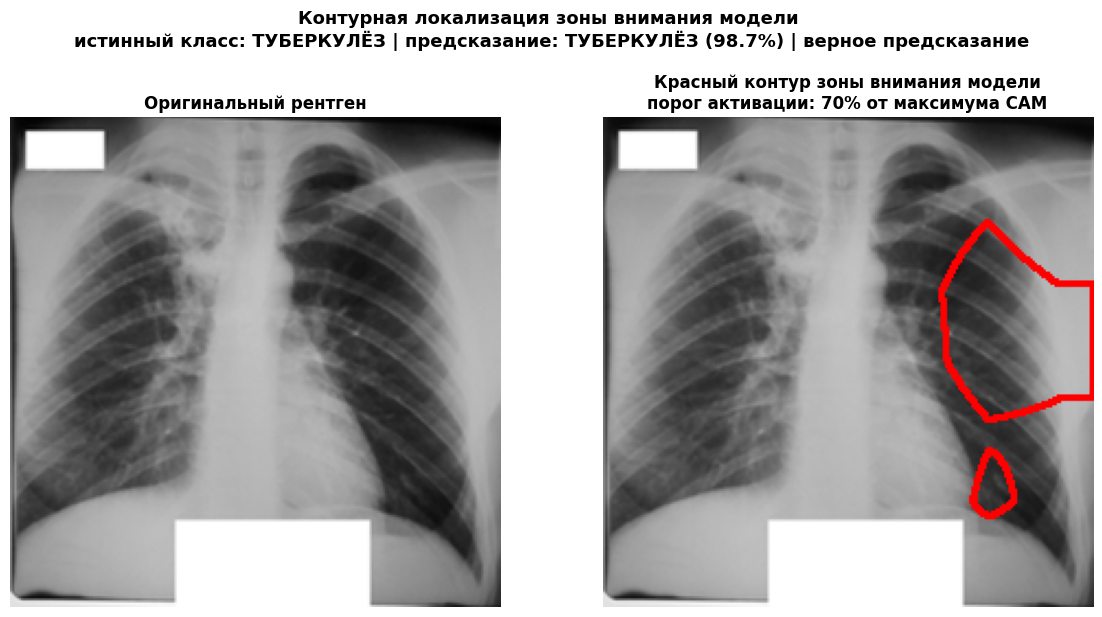

In [11]:
# случай туберкулёза
tb_row = df[df['label'] == 1].sample(n=1, random_state=42).iloc[0]
print(f"Снимок с туберкулёзом: {Path(tb_row['image_path']).name}")

# визуализация
visualize_contour_roi(tb_row['image_path'], "ТУБЕРКУЛЁЗ", improved_model, target_layer)

<a id=5.3.2.></a>
### 5.3.2. Валидация модели на снимке здоровой нормы

Проверим на отсутствие ложных срабатываний и «галлюцинаций» сети.

Снимок здоровой нормы: Normal-3405.png


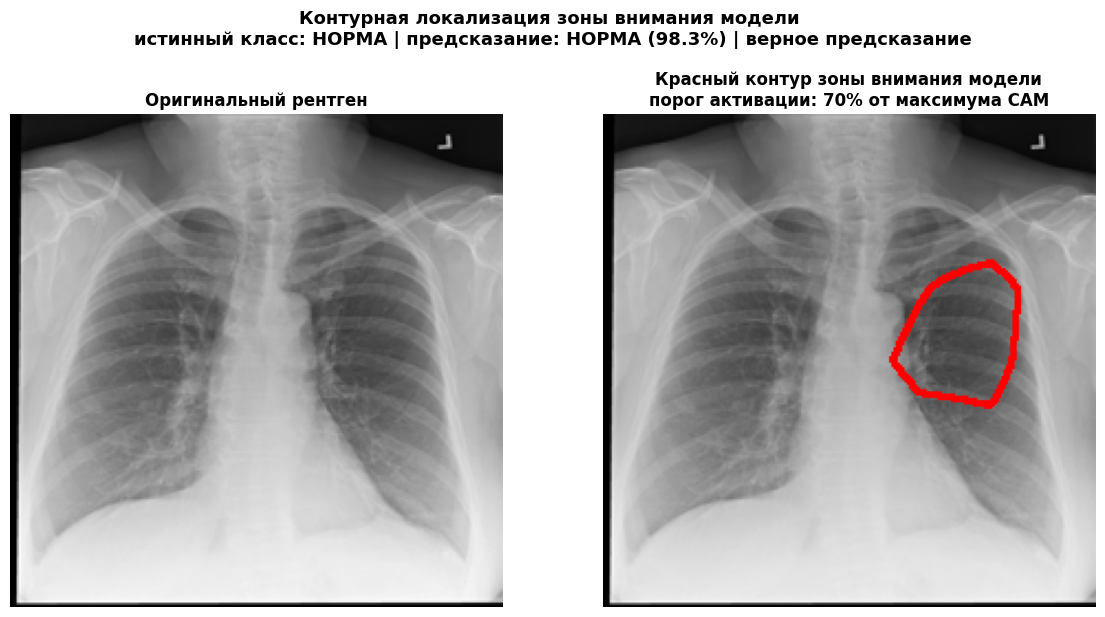

In [12]:
# здоровая норма
tb_row = df[df['label'] == 0].sample(n=1, random_state=42).iloc[0]
print(f"Снимок здоровой нормы: {Path(tb_row['image_path']).name}")

# визуализация
visualize_contour_roi(tb_row['image_path'], "НОРМА", improved_model, target_layer)

<a id=6></a>
## Вывод

В ходе выполнения второй части исследования **была успешно применена тяжёлая предобученная архитектура `MobileNetV2`** для задачи бинарной классификации рентгенограмм на предмет туберкулёза. В отличие от первой части проекта, где использовалась локальная рабочая станция и легковесная сеть, данный эксперимент потребовал привлечения облачных вычислительных мощностей (`Google Colab`, `GPU Tesla T4`) и организации персистентного хранилища (`Google Диск`). Это было продиктовано колоссальной ресурсоёмкостью операции: работа с изображениями высокого разрешения (`224×224`) и архитектурой, содержащей более 2,2 миллиона обучаемых параметров в режиме дообучения, предъявляет экстремальные требования к оперативной и видеопамяти.

Как и в предыдущем эксперименте, **конвейер аугментации данных был жёстко ограничен исключительно горизонтальным отражением.** Любые геометрические искажения недопустимы из-за билатеральной симметрии грудной клетки и риска создания неанатомических артефактов. Ключевым инженерным решением стало дублирование одноканального `grayscale`-изображения в трёхканальный `RGB`-формат с последующей нормализацией по стандартам `ImageNet`. Это позволило использовать мощнейшие предобученные веса без внесения синтетических искажений в сами медицинские пиксели, обеспечив полную совместимость с архитектурой `MobileNetV2`.

Собстваенно процесс обучения был разделён на два этапа. **Первый этап (Transfer Learning с замороженной свёрточной базой) позволил быстро сформировать надёжный baseline,** используя универсальные низкоуровневые признаки. Анализ динамики обучения базовой модели демонстрирует исключительно уверенный старт: уже к 10-й эпохе точность на валидации достигла `90.7%`, а функция потерь снизилась до `0.3117`. Минимальный разрыв между обучающей и валидационной выборками (всего `1.1%`) свидетельствует об идеальной регуляризации: замороженный `feature extractor` выступил в роли жёсткого ограничителя ёмкости, предотвратив переобучение на относительно небольшом датасете. Однако, поскольку рентгеновские лучи формируют 2D-проекцию с уникальным анатомическим шумом, отличным от натуральных фотографий, **для достижения клинического максимума потребовался второй этап (Fine-Tuning),** где мы разморозили слои архитектуры. Для предотвращения разрушения предобученных весов и катастрофического забывания была применена стратегия дифференциальных скоростей обучения, внедрён слой `Dropout (0.5)`, механизм `Mixed Precision` (`AMP`) и косинусное расписание (`Cosine Annealing`). **Графики обучения улучшенной модели показывают плавную и глубокую сходимость:** `Val Accuracy` достигла `93.0%` на 14-й эпохе, а функция потерь упала до впечатляющих `0.2050`. Использование `AMP` сделало градиентный спуск более устойчивым к шумам, а `Cosine Annealing` позволил модели аккуратно выйти в глобальный минимум. **Итоговый инференс подтвердил высочайшую диагностическую уверенность модели, которая составила 96.7%.**

**Важнейшим результатом данного этапа является сохранение двух независимых версий модели `MobileNetV2`** (`mobilenet_base.pth` и `mobilenet_improved.pth`), что открывает гибкие сценарии их интеграции в систему здравоохранения, но накладывает строгие инфраструктурные ограничения:
* **Базовая модель** (`Transfer Learning`, `90.7%`) обладает минимальным временем инференса и меньшей вычислительной нагрузкой. Идеально подходит для задач первичного, высокопоточного скрининга (например, при обработке потоковых флюорограмм), где важна скорость отклика, а требования к абсолютной максимальной точности могут быть слегка снижены.
* **Улучшенная модель** (`Fine-Tuning`, `93.0%`, уверенность `96.7%`) требует больше вычислительных ресурсов на один снимок, но обеспечивает максимальную диагностическую точность и глубину анализа. Модель предназначена для использования в качестве «второго мнения» в условиях стационарных фтизиатрических диспансеров и крупных больниц.

Необходимо чётко осознавать, что **переход к архитектурам уровня `MobileNetV2` кардинально меняет профиль потребления ресурсов.** Развёртывание улучшенной модели в условиях стационарного фтизиатрического диспансера или крупной больницы невозможно на стандартном офисном оборудовании или периферийных устройствах. Для обеспечения бесперебойного инференса требуется организация выделенного локального сервера, оснащённого дискретными `GPU` (уровня `NVIDIA Tesla T4`, `A10` или аналогов) с минимум `8 ГБ видеопамяти`. Кроме того, тяжеловесная архитектура диктует необходимость наличия пропускной способности локальной вычислительной сети (`ЛВС`) для мгновенной передачи «тяжёлых» `DICOM`-файлов из больничного архива `PACS` на сервер инференса. Если используется облачный хостинг, медицинскому учреждению необходимо предоставить канал корпоративного интернета с гарантированной высокой пропускной способностью и минимальными задержками. Таким образом, **данная система является строго централизованным, ресурсоёмким решением, предназначенным исключительно для технологически оснащённых стационаров.**

Для промышленной эксплуатации сохранённые веса моделей требуют дополнительной инженерной обёртки. В условиях стационара модель должна быть экспортирована в оптимизированный формат `ONNX` или скомпилирована через `TensorRT`, что сократит время инференса до десятков миллисекунд. Сама модель упаковывается в `Docker`-контейнер и разворачивается как микросервис (`REST API`), интегрируемый с больничным архивом `PACS` по стандарту `DICOM`, что обеспечит автоматический перехват новых рентгенограмм и возврат результата напрямую в рабочую станцию врача.

Внедрение алгоритмов ИИ в медицину невозможно без преодоления проблемы «чёрного ящика». Для того чтобы врач-фтизиатр мог доверять предсказаниям улучшенной модели, система должна генерировать карты активации (например, с помощью алгоритма `Grad-CAM`). **Визуализация зон внимания нейросети в виде контурной локализации, наложенной на оригинальный рентген, позволит врачу мгновенно верифицировать решение ИИ,** убедившись, что модель «смотрит» именно на патологическую каверну или инфильтрат, а не ошиблась из-за анатомического шума.

Наконец, **техническое внедрение модели неразрывно связано с адаптацией и обучением медицинского персонала.** Критически важным этапом является обучение врачей правилам взаимодействия с `CAD`-системой. Необходимо предотвратить эффект «автоматизации предвзятости» — ситуацию, когда врач начинает слепо доверять алгоритму, игнорируя собственный клинический опыт. Система должна быть позиционирована и внедрена строго как инструмент триажа и поддержки принятия решений, а юридическая и этическая ответственность за окончательный диагноз должна всегда оставаться за врачом. Интерфейс взаимодействия должен быть бесшовным, чтобы использование ИИ не увеличивало, а сокращало время на описание одного исследования, демонстрируя высокую клиническую интерпретируемость и практическую ценность в условиях современной фтизиатрии.